<a href="https://colab.research.google.com/github/annapurna-tumu6080/Bank-Customer-Churn-Prediction/blob/main/Untitled12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


I built a Bank Customer Churn Prediction model to identify customers likely to leave the bank. I performed data cleaning, removed irrelevant columns, conducted EDA, encoded categorical features, split the data into training and testing sets, trained Logistic Regression and Random Forest Classifier models, and evaluated them using Accuracy, Confusion Matrix, Precision, Recall, and F1-Score. Finally, I compared the models and selected the better-performing one.



Step 1: Import Libraries



In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Dataset

In [36]:
df = pd.read_csv('/content/Churn_Modelling.csv')
print(df.shape) #(Number of rows,number of columns)
df.head() #display the first rows

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Step 3: Understand Data

In [37]:
df.info()#column names,data types,missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [38]:
df.describe()#provides statistical summary like mean,min,max,std

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [39]:
df.isnull().sum() #checks for missing values

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


Step 4: Remove Unnecessary Columns

In [40]:
df.drop(['RowNumber','CustomerId','Surname'],
        axis=1,
        inplace=True)

Step 5: Exploratory Data Analysis

Churn Distribution

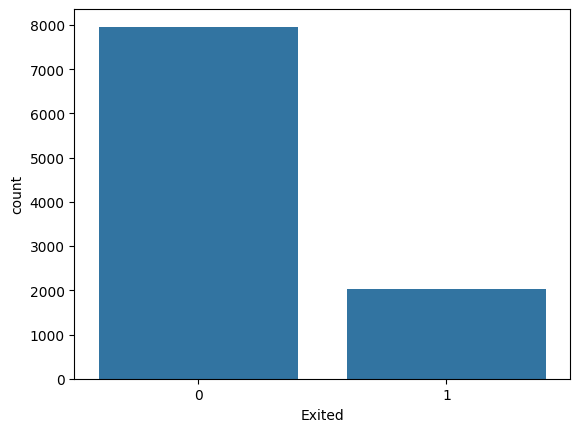

In [41]:
sns.countplot(x='Exited',data=df)  # exicted = 0--> Stayed
plt.show()                         #exicted = 1--> Left

Gender vs Churn

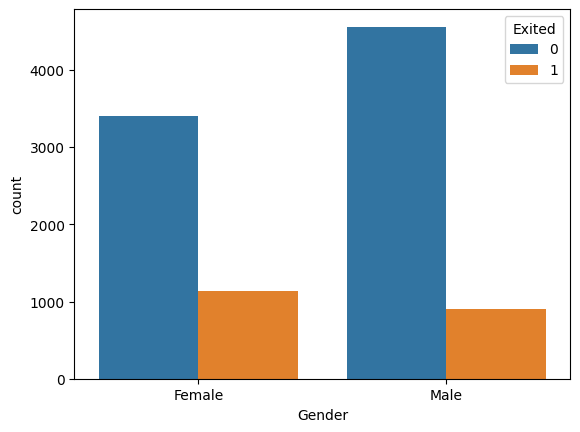

In [42]:
sns.countplot(x='Gender', # checks --> do males leave more?
              hue='Exited', #do females leave more?
              data=df)
plt.show()

Geography vs Churn

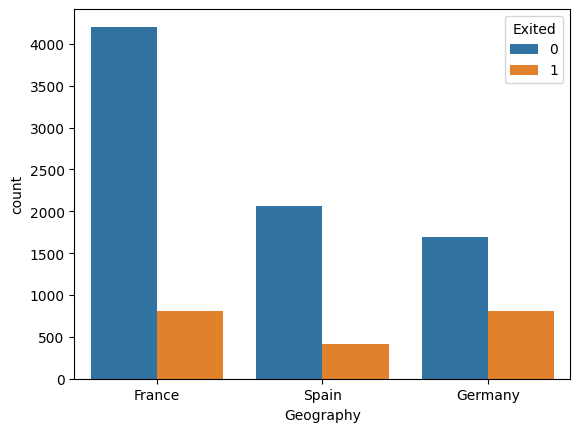

In [43]:
sns.countplot(x='Geography',
              hue='Exited',
              data=df)
plt.show()

Step 6: Encode Categorical Variables

In [44]:
df = pd.get_dummies(df,
                    columns=['Geography','Gender'],
                    drop_first=True) # covert text to numbers because ml models understand only numbers

Step 7: Feature & Target Separation

In [45]:
X = df.drop('Exited',axis=1) # x contains all input features like age,creditScore,Balance

y = df['Exited']  # target column like 0 = Stay, 1 = Leave

Step 8: Train-Test Split

In [46]:
from sklearn.model_selection import train_test_split  #imports the splitting function

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) # splits data: 80% training,20% testing

Step 9: Train Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression #imports logistic regression used for classification

model = LogisticRegression(max_iter=1000)  #creates the model max_iter = 1000,allows more iterations to help the model converge

model.fit(X_train,y_train) #training step-->the model learns relationships --> example- high age+low products--> more likely to leave

predictions = model.predict(X_test) #predicts 0,1,0,0,1 for unseen customers

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Step 10: Evaluate Model

In [48]:
from sklearn.metrics import accuracy_score  #measures prediction accuracy
from sklearn.metrics import confusion_matrix #
from sklearn.metrics import  classification_report# it provides precision,recall,f1-score,support all in one report

print("Accuracy:",
      accuracy_score(y_test,predictions))  # ex: 1800 correct out of 2000 --> 90%

print(confusion_matrix(y_test,predictions)) # correct stay predictions,correct leave predictions,wrong predictions

#1532customers stayed and were predicted correctly
#75 customers stayed but predicted as leaving
#304 customers left but predicted as staying
#89 customers left and were predicted correctly

print(classification_report(y_test,predictions)) #provides -->precision,recall,f1 score

Accuracy: 0.8105
[[1532   75]
 [ 304   89]]
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      1607
           1       0.54      0.23      0.32       393

    accuracy                           0.81      2000
   macro avg       0.69      0.59      0.60      2000
weighted avg       0.78      0.81      0.78      2000



Step 11: Train Random Forest Classifier

In [49]:
from sklearn.ensemble import RandomForestClassifier #imports random forest classification model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42)          #creates 100 decision trees
rf.fit(X_train,y_train)       #trains all trees
rf_pred = rf.predict(X_test)  #predicts churn using random forest

Step 12: Compare Models

In [50]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test,predictions)) # accuracy of logistic regression

print("Random Forest Accuracy:",
      accuracy_score(y_test,rf_pred)) # accuracy of random forest
#Whichever has higher accuracy is generally the better model

Logistic Regression Accuracy: 0.8105
Random Forest Accuracy: 0.8665


Step 13: Feature Importance

In [51]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns)
importance.sort_values(
    ascending=False).head(10)

,0
Age,0.236922
EstimatedSalary,0.147558
CreditScore,0.143338
Balance,0.141612
NumOfProducts,0.131486
Tenure,0.082080
IsActiveMember,0.040725
Geography_Germany,0.026190
HasCrCard,0.018454
Gender_Male,0.018421
